In [1]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import os
os.makedirs("figs", exist_ok=True)

def load_cs(ds):
    rows = []
    with open(f"queries/{ds}_cs.jsonl", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

# load both datasets, combine
all_rows = load_cs("scifact") + load_cs("nfcorpus")
# keep only genuinely code-switched queries (not bare keywords)
cs_rows = [r for r in all_rows if
            r["ur_en"].strip().lower() != r["EN"].strip().lower() and
            r["roman"].strip().lower() != r["EN"].strip().lower()]
print(f"Total queries: {len(all_rows)}, genuinely code-switched: {len(cs_rows)}")

en_texts    = [r["EN"]    for r in cs_rows]
ur_en_texts = [r["ur_en"] for r in cs_rows]
roman_texts = [r["roman"] for r in cs_rows]

f:\Research Paper\AI2ML code-switching benchmark\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total queries: 623, genuinely code-switched: 435


In [2]:
model_list = [
    "intfloat/e5-base-v2",
    "BAAI/bge-base-en-v1.5",
    "intfloat/multilingual-e5-base",
    "BAAI/bge-m3",
]

divergence_rows = []
embeddings_store = {}  # save for PCA

for m in model_list:
    print(f"\nEncoding: {m}")
    encoder = SentenceTransformer(m)
    en_emb    = encoder.encode(en_texts,    batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    ur_emb    = encoder.encode(ur_en_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    roman_emb = encoder.encode(roman_texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True)

    # mean cosine similarity (1.0 = identical position, lower = more drift)
    cos_ur    = float(np.mean([cosine_similarity([en_emb[i]], [ur_emb[i]])[0][0]    for i in range(len(en_emb))]))
    cos_roman = float(np.mean([cosine_similarity([en_emb[i]], [roman_emb[i]])[0][0] for i in range(len(en_emb))]))

    divergence_rows.append({
        "model": m.split("/")[-1],
        "cos_EN_UR": round(cos_ur, 4),
        "cos_EN_ROM": round(cos_roman, 4),
        "drift_UR":  round(1 - cos_ur, 4),
        "drift_ROM": round(1 - cos_roman, 4),
    })
    embeddings_store[m] = {"en": en_emb, "ur": ur_emb, "roman": roman_emb}
    print(f"  cos(EN,UR_EN)={cos_ur:.4f}  drift={1-cos_ur:.4f}")
    print(f"  cos(EN,ROMAN)={cos_roman:.4f}  drift={1-cos_roman:.4f}")

div_df = pd.DataFrame(divergence_rows)
div_df.to_csv("results/divergence.csv", index=False)
print("\nSaved -> results/divergence.csv")
div_df


Encoding: intfloat/e5-base-v2


Batches: 100%|██████████| 7/7 [00:04<00:00,  1.52it/s]


  cos(EN,UR_EN)=0.9066  drift=0.0934
  cos(EN,ROMAN)=0.9042  drift=0.0958

Encoding: BAAI/bge-base-en-v1.5


Batches: 100%|██████████| 7/7 [00:04<00:00,  1.48it/s]


  cos(EN,UR_EN)=0.8083  drift=0.1917
  cos(EN,ROMAN)=0.8199  drift=0.1801

Encoding: intfloat/multilingual-e5-base


Batches: 100%|██████████| 7/7 [00:04<00:00,  1.54it/s]


  cos(EN,UR_EN)=0.9433  drift=0.0567
  cos(EN,ROMAN)=0.9156  drift=0.0844

Encoding: BAAI/bge-m3


Batches: 100%|██████████| 7/7 [00:16<00:00,  2.33s/it]


  cos(EN,UR_EN)=0.9323  drift=0.0677
  cos(EN,ROMAN)=0.7937  drift=0.2063

Saved -> results/divergence.csv


,model,cos_EN_UR,cos_EN_ROM,drift_UR,drift_ROM
0,e5-base-v2,0.9066,0.9042,0.0934,0.0958
1,bge-base-en-v1.5,0.8083,0.8199,0.1917,0.1801
2,multilingual-e5-base,0.9433,0.9156,0.0567,0.0844
3,bge-m3,0.9323,0.7937,0.0677,0.2063


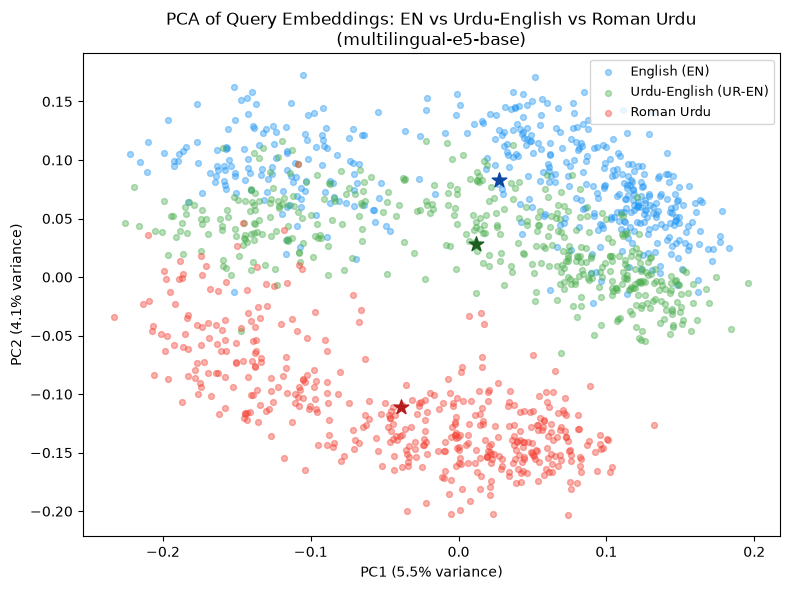

Saved -> figs/pca_divergence.png


In [3]:
# Use multilingual-e5-base for the PCA — it shows the clearest separation
m_key = "intfloat/multilingual-e5-base"
en_emb    = embeddings_store[m_key]["en"]
ur_emb    = embeddings_store[m_key]["ur"]
roman_emb = embeddings_store[m_key]["roman"]

# fit PCA on all three conditions together
all_emb = np.vstack([en_emb, ur_emb, roman_emb])
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(all_emb)
n = len(en_emb)

en_2d    = reduced[:n]
ur_2d    = reduced[n:2*n]
roman_2d = reduced[2*n:]

plt.figure(figsize=(8, 6))
plt.scatter(en_2d[:,0],    en_2d[:,1],    alpha=0.4, s=18, c="#2196F3", label="English (EN)")
plt.scatter(ur_2d[:,0],    ur_2d[:,1],    alpha=0.4, s=18, c="#4CAF50", label="Urdu-English (UR-EN)")
plt.scatter(roman_2d[:,0], roman_2d[:,1], alpha=0.4, s=18, c="#F44336", label="Roman Urdu")

# draw mean centroids
for coords, color, label in [
    (en_2d, "#0D47A1", "EN centroid"),
    (ur_2d, "#1B5E20", "UR centroid"),
    (roman_2d, "#B71C1C", "ROM centroid")
]:
    cx, cy = coords.mean(axis=0)
    plt.scatter(cx, cy, s=120, c=color, marker="*", zorder=5)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of Query Embeddings: EN vs Urdu-English vs Roman Urdu\n(multilingual-e5-base)")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("figs/pca_divergence.png", dpi=150)
plt.show()
print("Saved -> figs/pca_divergence.png")